# HW03 Problem 3: FashionMNIST Image Classification with PyTorch

**Name:** Sonica Sahetiya

This notebook reproduces the FashionMNIST image classification workflow from the section
*Building an Image Classifier with PyTorch* in `10_neural_nets_with_pytorch.ipynb`. It also
adds a plot of training accuracy across epochs.

**Contents**
1. Setup
2. Load FashionMNIST and create a training/validation split
3. Create the DataLoaders
4. Define the `ImageClassifier` network
5. Define the training and evaluation functions
6. Train the model
7. Plot training accuracy across epochs *(addition to the reference)*
8. Make predictions on validation examples

The notebook is self-contained. It runs from beginning to end after a kernel restart
(**Kernel → Restart & Run All**). FashionMNIST is downloaded to `datasets/` the first time it runs.

## 1. Setup

All imports are in this cell. The code then chooses the fastest available device: CUDA GPU,
then Apple Silicon GPU (MPS), then CPU. It also sets the plot font sizes the reference notebook uses.

In [1]:
import sys

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchmetrics
import torchvision
import torchvision.transforms.v2 as T
from torch.utils.data import DataLoader

assert sys.version_info >= (3, 10)

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

plt.rc("font", size=14)
plt.rc("axes", labelsize=14, titlesize=14)
plt.rc("legend", fontsize=14)
plt.rc("xtick", labelsize=10)
plt.rc("ytick", labelsize=10)

print(f"PyTorch {torch.__version__}, torchvision {torchvision.__version__}")
print(f"Using device: {device}")

PyTorch 2.14.0+cu130, torchvision 0.29.0+cu130
Using device: cpu


## 2. Load FashionMNIST and create a training/validation split

TorchVision provides FashionMNIST: 60,000 training images and 10,000 test images, each a 28×28
grayscale image of one of 10 clothing classes. The `toTensor` transform turns each image into a
`float32` tensor of shape `[1, 28, 28]`, with pixel values scaled to [0, 1].

The original training set is split with seed **42** into **55,000 training** and **5,000 validation**
examples.

In [2]:
toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

train_and_valid_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=False, download=True, transform=toTensor)

torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55_000, 5_000])

print(f"Training examples:   {len(train_data):,}")
print(f"Validation examples: {len(valid_data):,}")
print(f"Test examples:       {len(test_data):,}")

Training examples:   55,000
Validation examples: 5,000
Test examples:       10,000


Each entry is a tuple `(image, target)`. An image has the shape `[channels, rows, columns]`, with
one channel because the images are grayscale:

In [3]:
X_sample, y_sample = train_data[0]
print(f"Image shape: {tuple(X_sample.shape)}")
print(f"Image dtype: {X_sample.dtype}")
print(f"Label:       {y_sample} ({train_and_valid_data.classes[y_sample]})")

Image shape: (1, 28, 28)
Image dtype: torch.float32
Label:       9 (Ankle boot)


## 3. Create the DataLoaders

The DataLoaders serve batches of **32** images. Only the training loader shuffles its data, so each
epoch sees the training images in a new order. The seed is set again so the shuffling is reproducible.

In [4]:
torch.manual_seed(42)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

print(f"Batches per epoch: train={len(train_loader)}, valid={len(valid_loader)}, "
      f"test={len(test_loader)}")

Batches per epoch: train=1719, valid=157, test=313


## 4. Define the `ImageClassifier` network

`ImageClassifier` is a multilayer perceptron:

| Layer | Output size |
|---|---|
| `nn.Flatten()` | 784 (1 × 28 × 28) |
| `nn.Linear` + `nn.ReLU` | 300 |
| `nn.Linear` + `nn.ReLU` | 100 |
| `nn.Linear` (output) | 10 logits, one per class |

The network outputs raw logits, since `nn.CrossEntropyLoss` applies softmax internally.
The weights are initialized with seed 42.

In [5]:
class ImageClassifier(nn.Module):
    def __init__(self, n_inputs, n_hidden1, n_hidden2, n_classes):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_inputs, n_hidden1),
            nn.ReLU(),
            nn.Linear(n_hidden1, n_hidden2),
            nn.ReLU(),
            nn.Linear(n_hidden2, n_classes)
        )

    def forward(self, X):
        return self.mlp(X)


torch.manual_seed(42)
model = ImageClassifier(n_inputs=1 * 28 * 28, n_hidden1=300, n_hidden2=100,
                        n_classes=10).to(device)
xentropy = nn.CrossEntropyLoss()

print(model)
print(f"Trainable parameters: {sum([param.numel() for param in model.parameters()]):,}")

ImageClassifier(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): Linear(in_features=300, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=10, bias=True)
  )
)
Trainable parameters: 266,610


## 5. Define the training and evaluation functions

These two functions come from the reference notebook:

- `evaluate_tm()` switches the model to evaluation mode, turns off gradient tracking, and computes
  a torchmetrics metric over a whole DataLoader.
- `train2()` runs the mini-batch training loop. Each epoch it records:
  - the **training loss** (mean cross-entropy over the epoch's batches)
  - the **training accuracy** (accumulated over the epoch's batches)
  - the **validation accuracy** (computed with `evaluate_tm()` at the end of the epoch)

  It returns these in a `history` dictionary.

In [6]:
def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()  # reset the metric at the beginning
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)  # update it at each iteration
    return metric.compute()  # compute the final result at the end


def train2(model, optimizer, criterion, metric, train_loader, valid_loader,
           n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        for X_batch, y_batch in train_loader:
            model.train()
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train accuracy: {history['train_metrics'][-1]:.4f}, "
              f"valid accuracy: {history['valid_metrics'][-1]:.4f}")
    return history

## 6. Train the model

Training settings, as in the reference:

- **Loss:** `nn.CrossEntropyLoss`
- **Optimizer:** SGD with learning rate **0.1**
- **Metric:** torchmetrics multiclass accuracy over 10 classes
- **Epochs:** 20

In [7]:
n_epochs = 20
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)

history = train2(model, optimizer, xentropy, accuracy, train_loader,
                 valid_loader, n_epochs)

Epoch 1/20, train loss: 0.6060, train accuracy: 0.7814, valid accuracy: 0.8424


Epoch 2/20, train loss: 0.4061, train accuracy: 0.8496, valid accuracy: 0.8402


Epoch 3/20, train loss: 0.3630, train accuracy: 0.8661, valid accuracy: 0.8494


Epoch 4/20, train loss: 0.3355, train accuracy: 0.8768, valid accuracy: 0.8638


Epoch 5/20, train loss: 0.3154, train accuracy: 0.8829, valid accuracy: 0.8782


...

Epoch 16/20, train loss: 0.2078, train accuracy: 0.9196, valid accuracy: 0.8886


Epoch 17/20, train loss: 0.2033, train accuracy: 0.9233, valid accuracy: 0.8870


Epoch 18/20, train loss: 0.1991, train accuracy: 0.9230, valid accuracy: 0.8846


Epoch 19/20, train loss: 0.1916, train accuracy: 0.9266, valid accuracy: 0.8812


Epoch 20/20, train loss: 0.1876, train accuracy: 0.9286, valid accuracy: 0.8788


Summary of the history returned by `train2()`:

In [8]:
best_epoch = max(range(n_epochs), key=lambda i: history["valid_metrics"][i])
print(f"Final training loss:      {history['train_losses'][-1]:.4f}")
print(f"Final training accuracy:  {history['train_metrics'][-1]:.4f}")
print(f"Final validation accuracy: {history['valid_metrics'][-1]:.4f}")
print(f"Best validation accuracy: {history['valid_metrics'][best_epoch]:.4f} "
      f"(epoch {best_epoch + 1})")

Final training loss:      0.1876
Final training accuracy:  0.9286
Final validation accuracy: 0.8788
Best validation accuracy: 0.8886 (epoch 16)


## 7. Plot training accuracy across epochs

*This section is not in the reference notebook.* It plots the training accuracy from
`history["train_metrics"]` for each epoch.

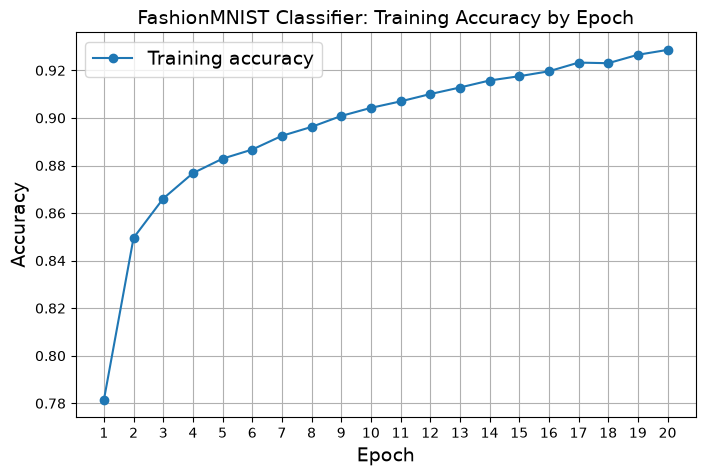

In [9]:
epochs = range(1, n_epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_metrics"], "o-", label="Training accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("FashionMNIST Classifier: Training Accuracy by Epoch")
plt.xticks(epochs)
plt.grid()
plt.legend()
plt.show()

Training accuracy climbs quickly over the first few epochs, then keeps rising more slowly.
The validation accuracy in the training log levels off at a lower value while training accuracy
keeps improving. This growing gap shows that the model starts to overfit in the later epochs.

## 8. Make predictions on validation examples

The trained model classifies the first three images of the first validation batch. For each image,
the predicted class is the index of its largest logit. The predictions are then compared with the
true labels.

In [10]:
model.eval()
X_new, y_new = next(iter(valid_loader))
X_new = X_new[:3].to(device)
with torch.no_grad():
    y_pred_logits = model(X_new)
y_pred = y_pred_logits.argmax(dim=1)  # index of the largest logit
y_pred

tensor([7, 4, 2])

In [11]:
[train_and_valid_data.classes[index] for index in y_pred]

['Sneaker', 'Coat', 'Pullover']

Now compare these predictions with the true labels:

In [12]:
y_new[:3]

tensor([7, 4, 2])

In [13]:
classes = train_and_valid_data.classes
for i, (pred, true) in enumerate(zip(y_pred.cpu(), y_new[:3])):
    result = "correct" if pred == true else "WRONG"
    print(f"Image {i}: predicted {classes[pred]!r}, true {classes[true]!r} -> {result}")

Image 0: predicted 'Sneaker', true 'Sneaker' -> correct
Image 1: predicted 'Coat', true 'Coat' -> correct
Image 2: predicted 'Pullover', true 'Pullover' -> correct


Softmax converts the logits into estimated class probabilities. The probabilities are moved to
the CPU before rounding, which MPS requires:

In [14]:
y_proba = F.softmax(y_pred_logits, dim=1).cpu()
y_proba.round(decimals=3)

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.8590, 0.0000,
         0.1410],
        [0.0000, 0.0000, 0.0070, 0.0000, 0.9930, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0040, 0.0000, 0.5920, 0.0000, 0.2120, 0.0000, 0.1910, 0.0000, 0.0010,
         0.0000]])

Only the top few classes matter for each image. `torch.topk()` returns the 4 largest logits and
their class indices, and softmax over those 4 gives their relative probabilities:

In [15]:
y_top4_values, y_top4_indices = torch.topk(y_pred_logits, k=4, dim=1)
y_top4_probas = F.softmax(y_top4_values, dim=1).cpu()

for i in range(len(y_top4_indices)):
    top4 = ", ".join(f"{classes[index]} ({proba:.3f})"
                     for index, proba in zip(y_top4_indices[i], y_top4_probas[i]))
    print(f"Image {i}: {top4}")

Image 0: Sneaker (0.859), Ankle boot (0.141), Sandal (0.000), Trouser (0.000)
Image 1: Coat (0.993), Pullover (0.007), Shirt (0.000), Bag (0.000)
Image 2: Pullover (0.593), Coat (0.212), Shirt (0.192), T-shirt/top (0.004)


The images and their predictions:

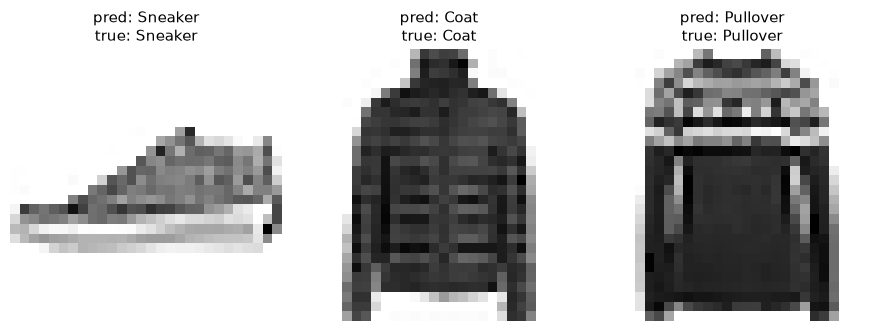

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3.5))
for i, ax in enumerate(axes):
    ax.imshow(X_new[i].cpu().squeeze(), cmap="binary")
    ax.set_title(f"pred: {classes[y_pred[i]]}\ntrue: {classes[y_new[i]]}", fontsize=11)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Conclusion

The `ImageClassifier` MLP (784 → 300 → 100 → 10, ReLU activations) was trained for 20 epochs
with cross-entropy loss and SGD (learning rate 0.1). It reaches about 93% training accuracy and
about 88% validation accuracy. The training accuracy plot shows steady improvement. The gap between
training and validation accuracy grows in later epochs, which points to mild overfitting.
The model classified the sampled validation images, and its softmax probabilities show which
visually similar classes (such as Pullover, Coat and Shirt) it confuses.